In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from alpha.analysist import datastore

In [3]:
ds = datastore.DataStore(live=False)

In [4]:
td = ds.indicators(symbol="000660", label="OFI_KF", start="2026-09-02", end="2026-09-02")

In [5]:
td.split_by_gap(max_gap="1min").segments[1].base.times[[0,-1]]

DatetimeIndex(['2026-09-02 10:38:14', '2026-09-02 11:39:47'], dtype='datetime64[ns]', name='t', freq=None)

In [6]:
td.tslice(start='2026-09-02 10:38:20', end='2026-09-02 11:32:47').where(lambda df: (df["line"]=="level") & (df['value']>=2)).base.times

DatetimeIndex(['2026-09-02 10:59:34'], dtype='datetime64[ns]', name='t', freq=None)

In [7]:
kalman = td.tslice(start='2026-09-02 10:59:34', end='2026-09-02 11:29:34')

In [8]:
price = ds.ticks(symbol="000660", start="2026-09-02", end="2026-09-02")

In [9]:
price = price.calc('mid', 'bid', '+', 'ask').calc('mid', 'mid', '/', 2)

In [10]:
mid_price = price.tslice(start='2026-09-02 10:59:34', end='2026-09-02 11:29:34').relative('mid', replace=True)

In [27]:
kalman.series()

['indicator@OFI_KF.value[000660|lead]',
 'indicator@OFI_KF.value[000660|obs_var]',
 'indicator@OFI_KF.value[000660|nis]',
 'indicator@OFI_KF.value[000660|level]',
 'indicator@OFI_KF.value[000660|slope]']

In [26]:
kalman.add(mid_price).plot(layout=[
    ('indicator@OFI_KF.value[000660|level]','tick_relative@mid.relative[000660]'),
    ('indicator@OFI_KF.value[000660|lead]','indicator@OFI_KF.value[000660|slope]'),
    ('indicator@OFI_KF.value[000660|nis]','indicator@OFI_KF.value[000660|obs_var]')
])

KeyError: "layout 선택자 'i' 를 찾을 수 없습니다. 사용 가능한 name: ['indicator@OFI_KF', 'tick_relative@mid'] (정확한 컬럼/시리즈 이름은 Tdata.series()로 확인할 수 있다)"

In [28]:
bar_sam = ds.bars(symbol='005930', start="2026-09-02", end="2026-09-02", seconds=60)
bar_sh = ds.bars(symbol='000660', start="2026-09-02", end="2026-09-02", seconds=60)

DatabaseError: Execution failed on sql 'SELECT * FROM bar WHERE symbol IN (?) AND dt >= ? AND dt <= ? AND (seconds = ?) ORDER BY dt': disk I/O error

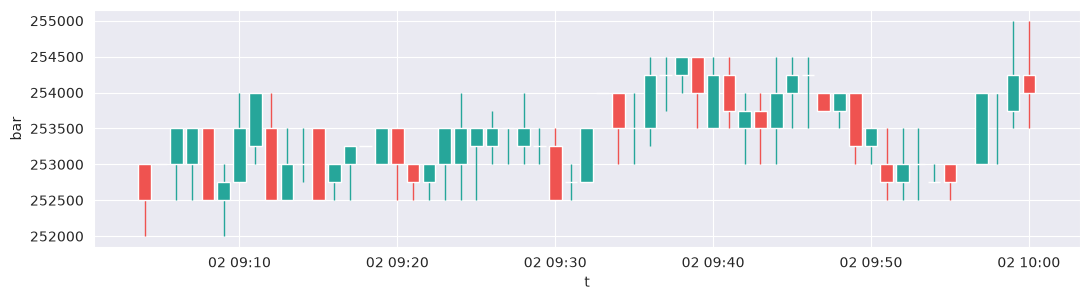

(<Figure size 1100x310 with 1 Axes>, [<Axes: xlabel='t', ylabel='bar'>])

In [16]:
bar.tslice(start="2026-09-02 09:00", end="2026-09-02 10:00").plot(kind={'bar@60':'candle'})

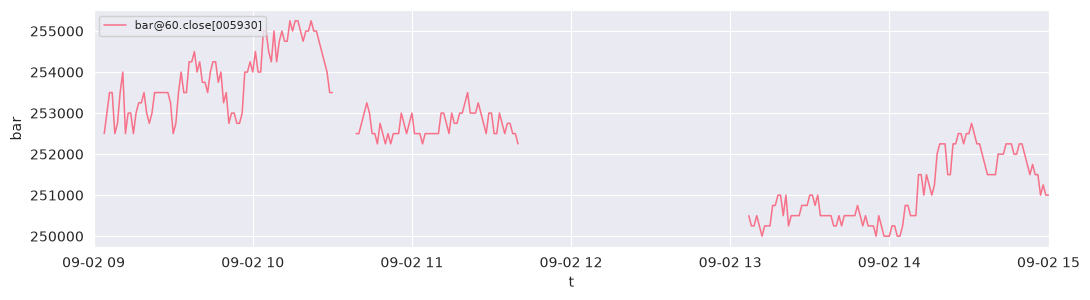

(<Figure size 1100x310 with 1 Axes>, [<Axes: xlabel='t', ylabel='bar'>])

In [24]:
bar.time_frame(start="2026-09-02 09:00", end="2026-09-02 15:00", mode='min').plot(columns=["close"])